EXPERIMENT 06 - POST LAB
PCA and Clustering on Titanic Dataset
Name    : R. Karthik
Roll No : 25EU02904

Titanic Dataset Shape:
(891, 12)

First Five Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2    

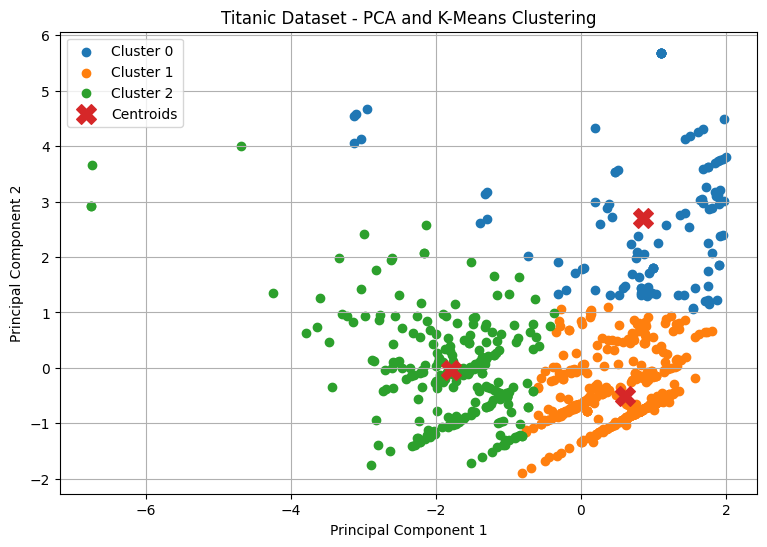


Cluster-wise Feature Means:
         Pclass    Age  SibSp  Parch   Fare
Cluster                                    
0          2.58  12.64   2.42   1.92  47.02
1          2.76  27.87   0.23   0.12  12.28
2          1.12  41.14   0.37   0.29  72.16

POST-LAB COMPLETED SUCCESSFULLY
PCA and K-Means were applied to the Titanic dataset.
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 06 - POST LAB
# PCA and K-Means Clustering on Titanic Dataset
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("=" * 60)
print("EXPERIMENT 06 - POST LAB")
print("PCA and Clustering on Titanic Dataset")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Titanic Dataset
# ------------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/"
    "datasciencedojo/datasets/master/titanic.csv"
)

titanic = pd.read_csv(
    url
)

print("\nTitanic Dataset Shape:")
print(
    titanic.shape
)

print("\nFirst Five Rows:")
print(
    titanic.head()
)

# ------------------------------------------------------------
# 2. Select Numerical Features
# ------------------------------------------------------------

features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X = titanic[
    features
].copy()

# ------------------------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------------------------

X["Age"] = (
    X["Age"]
    .fillna(
        X["Age"].median()
    )
)

X["Fare"] = (
    X["Fare"]
    .fillna(
        X["Fare"].median()
    )
)

print("\nMissing Values:")
print(
    X.isnull().sum()
)

# ------------------------------------------------------------
# 4. Standardize Titanic Features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

# ------------------------------------------------------------
# 5. Apply PCA
# ------------------------------------------------------------

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print(
    "\nPCA Transformed Shape:"
)

print(
    X_pca.shape
)

print(
    "\nVariance Retained:"
)

print(
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

# ------------------------------------------------------------
# 6. Find Optimal K Using Silhouette Score
# ------------------------------------------------------------

silhouette_scores = []

k_values = range(
    2,
    7
)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(
        X_pca
    )

    score = silhouette_score(
        X_pca,
        labels
    )

    silhouette_scores.append(
        score
    )

best_k = list(k_values)[
    np.argmax(
        silhouette_scores
    )
]

print(
    "\nSilhouette Scores:"
)

for k, score in zip(
    k_values,
    silhouette_scores
):
    print(
        f"k={k}: {score:.4f}"
    )

print(
    f"\nBest k: {best_k}"
)

# ------------------------------------------------------------
# 7. Final K-Means
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    X_pca
)

# Add cluster labels
titanic_result = titanic[
    features
].copy()

titanic_result[
    "Cluster"
] = cluster_labels

print(
    "\nCluster Distribution:"
)

print(
    titanic_result[
        "Cluster"
    ].value_counts().sort_index()
)

# ------------------------------------------------------------
# 8. PCA + K-Means Visualization
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)

for cluster in range(
    best_k
):

    mask = cluster_labels == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}"
    )

# Centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Titanic Dataset - PCA and K-Means Clustering"
)

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 9. Cluster Summary
# ------------------------------------------------------------

print(
    "\nCluster-wise Feature Means:"
)

summary = titanic_result.groupby(
    "Cluster"
)[features].mean()

print(
    summary.round(2)
)

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("POST-LAB COMPLETED SUCCESSFULLY")
print("PCA and K-Means were applied to the Titanic dataset.")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)